# Models Experimentation Notebook for IFood Data Science Technical Case

O direcionamento das ofertas corretas para os clientes corretos na hora certa traz grandes impactos para um negócio, uma vez que pode otimizar o uso de recuros, mas, principalmente, fortalecer o engajamento e relacionamento de longo prazo com os clientes.

Existem diferentes formas de endereçarmos e modelarmos esse desafio. Em nossa resolução, utilizaremos uma abordagem de Sistemas de Recomendação, os quais são amplamente utilizados por grandes empresas como Amazon e Netflix.

Existem diferentes estratégias para implementação de sistemas de recomendação, as quais usualmente podem ser classificadas em dois grandes grupos:
- **Content-Based Filtering**: em que o foco são as características/conteúdos dos items e usuários como base para as escolhas. Por exemplo, se um usuário costuma comprar um determinado produto, provavelmente ele também vai ter interesse em outros produtos com características semelhantes. E isso talvez varie com o gênero e faixa etária dos usuários. 
    - **Em nosso caso de uso, poderíamos aproveitar características das ofertas - como os canais de divulgação, valor mínimo, tamanho do desconto, tipo de oferta, duração, etc - e dos usuários - como o gênero, idade, tempo que está registrado na plataforma, etc - para modelar os dados a serem utilizados de base para as recomendações.**
- **Collaborative-Based Filtering**: em que o foco está na interação entre usuários e itens, assim como nas relações em comum entre usuários. Por exemplo, se um usuário semelhante a você comprou um produto X, talvez você também possa gostar desse produto. Daí vem o termo **Colaborativo**. 
    - **Em nosso caso de uso, resolvemos modelar essas relações construindo uma matriz de interação, que diz com quais ofertas cada usuário interagiu. Interagir para a gente significa ter recebido, visto ou completado uma oferta. Além disso, para cada tipo de interação atribuímos um peso: oferta recebida tem peso 1, oferta vista tem peso 3 e oferta completada tem peso 5. Por fim, os valores de cada par (usuário, oferta) está modelado como a média dos pesos dos tipos de interação com a oferta.** 
    - Essa modelagem busca fazer um paralelo com o que vemos, por exemplo, no cenário de avaliações de filmes, em que os valores das interações (usuário, filme) são as notas (ratings) dadas pelos usuários. Em nosso caso, entendemos que um usuário não tem controle direto sobre as **ofertas que recebe**, por isso elas receberam os pesos mais baixos. Todavia, se o usuário resolver **ver a oferta**, isso indica que ele demonstra algum interesse, por isso a pontuação média 3. Por fim, se o usuário utilizou a oferta, é como se ele tivesse dado pontuação máxima, e por isso o 5.

Além desses dois grupos, existem diferentes técnicas para a aplicação de uma **abordagem híbrida**, que combina o melhor dos dois mundos.
Neste case, com o objetivo de se construir uma PoC (Prova de Conceito) simples que demonstre a viabilidade e valor que essa abordagem pode trazer para o problema de direcionamento de ofertas, assim como se aproveitar de algoritmos já implementados no PySpark, vamos empregar a técnica **Alternating Least Squares (ALS)**, que é um método de filtragem colaborativa baseado em modelo.

## 1. Import Libraries

In [89]:
import os
import json
import shutil
import numpy as np
from itertools import chain
import matplotlib.pyplot as plt

from pyspark.sql.functions import col, sum, when, count, to_date, year, avg, coalesce, create_map, lit, desc, size, explode, posexplode, first, collect_set, expr, array_intersect
from pyspark.sql import SparkSession
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.recommendation import ALS, ALSModel
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder, CrossValidator

# Cria a sessão Spark local
spark = SparkSession.builder.appName("ifoodModelExperimenting").master("local[*]").getOrCreate()

# Verifica
print(spark.version)

4.0.1


## 2. Utilities

In [57]:
def get_columns_with_nulls(dataframe):
    return dataframe.select([sum(col(c).isNull().cast("int")).alias(c) for c in dataframe.columns])

def info_alternative(dataframe):
    n_rows = dataframe.count()
    print(f"Number of rows: {n_rows}")
    print(f"Number of columns: {len(dataframe.columns)}")
    number_of_nans_in_cols = get_columns_with_nulls(dataframe)
    print("#\tColumn\t\tNon-Null Count\t\tDtype")
    print("---\t------\t\t--------------\t\t-----")
    for index, (col, col_type) in enumerate(dataframe.dtypes):
        print(f"{index}\t{col}\t\t{n_rows - number_of_nans_in_cols.first()[col]}\t\t{col_type}")


def create_id_int_column(data, column_map, original_column_name, new_column_name):
    mapping_expr = create_map([lit(x) for x in chain(*column_map.items())])

    return data.withColumn(
        new_column_name,
        coalesce(
            mapping_expr[col(original_column_name)],
            lit(-1)   # default se não achar a chave
            )
        )

def map_back_from_int_to_id(data, column_map, original_column_name, new_column_name):
    mapping_expr = create_map([lit(x) for x in chain(*column_map.items())])

    df = data.withColumn(
        original_column_name,
        mapping_expr[col(original_column_name)].cast("string"),
        )
    
    return df.withColumnRenamed(original_column_name, new_column_name)


def save_json(data, json_path):
    parent_path = os.path.dirname(json_path)
    os.makedirs(parent_path, exist_ok=True)

    with open(json_path, "w") as file:
        json.dump(data, file)

def load_json(json_path):
    with open(json_path, "r") as file:
        data = json.load(file)
    
    return data

def save_processed_data(data, path_data):
    tmp_path = path_data + "_tmp"
    data.coalesce(1).write.json(tmp_path, mode="overwrite")
    filename = [f for f in os.listdir(tmp_path) if f.startswith("part-")][0]
    shutil.move(os.path.join(tmp_path, filename), path_data)
    shutil.rmtree(tmp_path)

def get_real_id_from_int(map, id_int):
    return list(filter(lambda key: map[key] == id_int, map))

In [46]:
def plot_bars(axes, data_values, data_labels, data_colors, title, x_label, y_label):
    data_colors = data_colors if data_colors else "tab:blue"
    axes.bar(x=data_labels, height=data_values, color=data_colors)
    axes.set_title(title)
    axes.set_xlabel(x_label)
    axes.set_ylabel(y_label)

    return axes

def plot_hist(axes, data_values, n_bins, title, x_label, y_label, data_mean=None, data_median=None, mean_color="tab:red", median_color="tab:green"):

    axes.hist(data_values, bins=n_bins)

    if data_mean is not None:
        axes.axvline(x=data_mean, color=mean_color, linestyle="dashed")
        axes.text(data_mean, axes.get_ylim()[1]-100, "Média", color=mean_color)
    if data_median is not None:
        axes.axvline(x=data_median, color=median_color, linestyle="dashed")
        axes.text(data_median, axes.get_ylim()[1]-200, "Mediana", color=median_color)

    axes.set_title(title)
    axes.set_xlabel(x_label)
    axes.set_ylabel(y_label)

    return axes

def create_dataframe_from_recommendations(recommendations, user_col="account_id_int", item_col="offer_id_int"):
     
    df_flat_with_pos = recommendations.select(user_col, posexplode("recommendations").alias("rank", "rec"))\
        .select(
            user_col,
            (col("rank")+1).alias("rank"),
            col(f"rec.{item_col}").alias(item_col),
            col("rec.rating").alias("rating")
    )

    df_with_cols_expanded = df_flat_with_pos.groupBy(user_col).pivot("rank").agg(
        first(item_col).alias(item_col),
        first("rating").alias("rating")
    )

    return df_with_cols_expanded

## 3. Loading Data

In [4]:
path_user_offer = "ifood-case/data/processed/user_offer_interactions.json"
path_account_id = "ifood-case/data/processed/account_id_map.json"
path_offer_id = "ifood-case/data/processed/offer_id_map.json"

user_offer_interactions = spark.read.json(path_user_offer)
account_id_map = load_json(json_path=path_account_id)
offer_id_map = load_json(json_path=path_offer_id)

print(f"There are {user_offer_interactions.count()} interactions")

There are 63288 interactions


In [6]:
offer_id_map

{'0b1e1539f2cc45b7b9fa7c272da2e1d7': 0,
 '4d5c57ea9a6940dd891ad53e9dbe8da0': 1,
 '9b98b8c7a33c4b65b9aebfe6a799e6d9': 2,
 'f19421c1d4aa40978ebb69ca19b0e20d': 3,
 'fafdcd668e3743c1bb461111dcafc2a4': 4,
 'ae264e3637204a6fb9bb56bc8210ddfd': 5,
 '5a8bc65990b245e5a138643cd4eb9837': 6,
 '2298d6c36e964ae4a3e7e9706d1fb8c2': 7,
 '2906b810c7d4411798c6938adc9daaa5': 8,
 '3f207df678b143eea3cee63160fa8bed': 9}

## 4. Training Models

In [5]:
train_set, test_set = user_offer_interactions.randomSplit([0.8, 0.2], seed=42)

print(f"There are {train_set.count()} training samples and {test_set.count()} testing samples.")

There are 50806 training samples and 12482 testing samples.


In [6]:
train_set.show(5)

+--------------------+--------------+------------+--------------------+------------+
|          account_id|account_id_int|event_levels|            offer_id|offer_id_int|
+--------------------+--------------+------------+--------------------+------------+
|0009655768c64bdeb...|         15942|         3.0|f19421c1d4aa40978...|           3|
|0009655768c64bdeb...|         15942|         3.0|fafdcd668e3743c1b...|           4|
|0020ccbbb6d84e358...|           505|         3.0|2298d6c36e964ae4a...|           7|
|0020ccbbb6d84e358...|           505|         3.0|9b98b8c7a33c4b65b...|           2|
|003d66b6608740288...|         11137|         2.0|5a8bc65990b245e5a...|           6|
+--------------------+--------------+------------+--------------------+------------+
only showing top 5 rows


In [ ]:
save_processed_data(data=train_set, path_data="ifood-case/data/processed/train_data_80.json")
save_processed_data(data=test_set, path_data="ifood-case/data/processed/test_data_20.json")

O algoritmo ALS só consegue fazer previsões para usuários e ofertas que ele viu durante o treinamento. Para casos novos, ele retorna NaN.
Conforme vemos abaixo, existem usuários no conjunto de teste que não aparecem no treinamento. Como esse número representa uma parte pequena do conjunto de testes, vamos ignorá-los por enquanto. Mas para resultados mais precisos é necessário implementarmos outra estratégia de divisão dos dados que garanta que todos os usuários e itens do teste também estejam no treinamento.

In [9]:
train_users = train_set.select("account_id_int").distinct()
test_users  = test_set.select("account_id_int").distinct()
train_items = train_set.select("offer_id_int").distinct()
test_items  = test_set.select("offer_id_int").distinct()

new_users = test_users.join(train_users, on="account_id_int", how="left_anti")
new_items = test_items.join(train_items, on="offer_id_int", how="left_anti")

print("Usuários no teste que não aparecem no treino:", new_users.count())
print("Ofertas no teste que não aparecem no treino:", new_items.count())


Usuários no teste que não aparecem no treino: 144
Ofertas no teste que não aparecem no treino: 0


A seguir, instanciamos o modelo ALS que vai ficar responsável por, posteriormente, predizer valores de "event_level" para novos pares de (usuário, oferta). Ele utiliza as colunas:
- **account_id_int**: para representar os usuários.
- **offer_id_int**: para representar as ofertas.
- **event_levels**: para representar a força da interação entre usuários e ofertas.

Além disso, esse modelo possui alguns hiperparâmetros com os quais gostaríamos de experimentar:
- **rank**: que determina o tamanho do vetor latente. Gostaríamos de experimentá-lo com os valores 13 (quantidade de colunas de features juntando os 3 conjuntos de dados originais) e 20 (teto do intervalo).
- **maxIter**: número máximo de iterações alternadas do modelo durante o treinamento. Gostaríamos de testá-lo com os valores 15 e 20 (número comum de iterações).
- **regParam**: coeficiente de regularização da função de custo, usado para reduzir os riscos de overfittings. Gostaríamos de testá-lo com valores comumente empregados, como 0,01 e 0,1.

Por questões de limitação do hardware onde estou executando os experimentos, não conseguiremos experimentar com todos esses parâmetros e seguiremos com: **rank 10**, **maxIter 18** e **regParam 0.1**. Nesse conjunto de dados, poderíamos construir um GridSearch com os diversos valores dos hiperparâmetros que gostaríamos de verificar e aplicar estratégias como Train-Validation split ou até mesmo Cross Validation com diferentes valores de Folds. Entretanto, isso vai ficar para trabalhos futuros.

Para avaliar o modelo, vamos utilizar o **RegressionEvaluator** com a métrica de **Root Mean Squared Error (RMSE)**, já que estamos tratando a predição da força de interação entre usuários e ofertas como um problema de regressão.

In [10]:
als_model = ALS(
    userCol="account_id_int",
    itemCol="offer_id_int",
    ratingCol="event_levels",
    coldStartStrategy="drop",
    nonnegative=True,
    maxIter=18,
    regParam=0.1,
    rank=10
)

# param_grid = ParamGridBuilder()\
#     .addGrid(als_model.rank, [13,20])\
#     .addGrid(als_model.maxIter, [15,20])\
#     .addGrid(als_model.regParam, [0.01, 0.1])\
#     .build()

evaluator = RegressionEvaluator(metricName="rmse", labelCol="event_levels", predictionCol="prediction")

In [ ]:
# train_valid_split_validator = TrainValidationSplit(
#     estimator=als_model,
#     estimatorParamMaps=param_grid,
#     evaluator=evaluator
# )

# cross_validator = CrossValidator(
#     estimator=als_model,
#     estimatorParamMaps=param_grid,
#     evaluator=evaluator,
#     numFolds=3,
#     seed=42
# )

In [11]:
train_set.cache()
# final_model = train_valid_split_validator.fit(train_set)
# final_model = cross_validator.fit(train_set)
final_model = als_model.fit(train_set)

25/09/28 08:16:09 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


In [12]:
final_model.save('ifood-case/models/als_rank10_reg01_maxIter18')

25/09/28 08:16:22 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
25/09/28 08:16:22 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
25/09/28 08:16:22 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
25/09/28 08:16:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
25/09/28 08:16:23 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
25/09/28 08:16:28 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
25/09/28 08:16:28 WARN MemoryManager: Total allocation exceeds 95.00%

In [13]:
best_model = final_model
best_model

ALSModel: uid=ALS_bdf2261f67e0, rank=10

In [14]:
pred_train = best_model.transform(train_set)
print(f"RMSE Train set {evaluator.evaluate(pred_train)}")

RMSE Train set 0.19893227039839964


## 5. Evaluating Models and Generating Recommendations

In [15]:
pred_test = best_model.transform(test_set)
print(f"RMSE Teste set {evaluator.evaluate(pred_test)}")

RMSE Teste set 0.7043784026895958


In [ ]:
# test_set = spark.read.json("ifood-case/data/processed/test_data_20.json")
# best_model = ALSModel.load("ifood-case/models/als_rank10_reg01_maxIter18")
# pred_test = best_model.transform(test_set)
# print(f"RMSE Teste set {evaluator.evaluate(pred_test)}")

RMSE Teste set 0.7043784026895955


In [29]:
top3_recommends_per_user = best_model.recommendForAllUsers(3)
top3_recommends_per_user.first()

Row(account_id_int=0, recommendations=[Row(offer_id_int=2, rating=2.467855215072632), Row(offer_id_int=7, rating=2.2559800148010254), Row(offer_id_int=4, rating=2.0350418090820312)])

In [45]:
df_recommendations = create_dataframe_from_recommendations(recommendations=top3_recommends_per_user, user_col="account_id_int", item_col="offer_id_int")
df_recommendations.show(5)

+--------------+--------------+---------+--------------+---------+--------------+---------+
|account_id_int|1_offer_id_int| 1_rating|2_offer_id_int| 2_rating|3_offer_id_int| 3_rating|
+--------------+--------------+---------+--------------+---------+--------------+---------+
|         16574|             7|2.9007883|             2|2.8491783|             4|2.8280888|
|         12027|             7|2.9069138|             2|2.8762786|             4|2.7693207|
|         15447|             8|2.8537314|             4|2.6243315|             7|2.5132642|
|          7982|             0|2.5691333|             7|1.8139073|             4|1.7171682|
|         14450|             0|2.7092798|             4|2.2783785|             8| 2.253498|
+--------------+--------------+---------+--------------+---------+--------------+---------+
only showing top 5 rows


In [48]:
map_int_to_account_id = {v:k for k,v in account_id_map.items()}
map_int_to_offer_id = {v:k for k,v in offer_id_map.items()}

In [ ]:
df_recommendations = map_back_from_int_to_id(data=df_recommendations, column_map=map_int_to_account_id, original_column_name="account_id_int", new_column_name="account_id")
df_recommendations = map_back_from_int_to_id(data=df_recommendations, column_map=map_int_to_offer_id, original_column_name="1_offer_id_int", new_column_name="offer_id_1")
df_recommendations = map_back_from_int_to_id(data=df_recommendations, column_map=map_int_to_offer_id, original_column_name="2_offer_id_int", new_column_name="offer_id_2")
df_recommendations = map_back_from_int_to_id(data=df_recommendations, column_map=map_int_to_offer_id, original_column_name="3_offer_id_int", new_column_name="offer_id_3")

save_processed_data(data=df_recommendations, path_data="ifood-case/data/processed/recommendations_per_user.json")

In [66]:
df_recommendations.show(5)

+--------------------+--------------------+---------+--------------------+---------+--------------------+---------+
|          account_id|          offer_id_1| 1_rating|          offer_id_2| 2_rating|          offer_id_3| 3_rating|
+--------------------+--------------------+---------+--------------------+---------+--------------------+---------+
|4fa5fba731c94e749...|2298d6c36e964ae4a...|2.9007883|9b98b8c7a33c4b65b...|2.8491783|fafdcd668e3743c1b...|2.8280888|
|756418e9da164ec9b...|2298d6c36e964ae4a...|2.9069138|9b98b8c7a33c4b65b...|2.8762786|fafdcd668e3743c1b...|2.7693207|
|e5476f13ac174d3ab...|2906b810c7d441179...|2.8537314|fafdcd668e3743c1b...|2.6243315|2298d6c36e964ae4a...|2.5132642|
|c854f458625c405c8...|0b1e1539f2cc45b7b...|2.5691333|2298d6c36e964ae4a...|1.8139073|fafdcd668e3743c1b...|1.7171682|
|b027423ac3f44c6f9...|0b1e1539f2cc45b7b...|2.7092798|fafdcd668e3743c1b...|2.2783785|2906b810c7d441179...| 2.253498|
+--------------------+--------------------+---------+-------------------

25/09/28 09:18:46 WARN DAGScheduler: Broadcasting large task binary with size 1022.5 KiB


## 6. Checking Predictions X Historical Data

In [90]:
real_offers = test_set.groupBy("account_id_int") \
    .agg(collect_set("offer_id_int").alias("offers_real"))

pred_offers = top3_recommends_per_user.select(
    "account_id_int",
    expr("transform(recommendations, x -> x.offer_id_int)").alias("offers_pred")
)

verification = real_offers.join(pred_offers, on="account_id_int", how="inner")
verification = verification.withColumn(
    "intersections", size(array_intersect("offers_real", "offers_pred"))
)

save_processed_data(data=verification, path_data="ifood-case/data/processed/real_pred_verification.json")

In [91]:
verification.show(5, truncate=False)

+--------------+-----------+-----------+-------------+
|account_id_int|offers_real|offers_pred|intersections|
+--------------+-----------+-----------+-------------+
|1             |[5]        |[8, 1, 4]  |0            |
|2             |[7]        |[2, 0, 4]  |0            |
|3             |[2, 4]     |[1, 7, 4]  |1            |
|4             |[7, 9]     |[2, 7, 4]  |1            |
|8             |[0]        |[8, 3, 4]  |0            |
+--------------+-----------+-----------+-------------+
only showing top 5 rows


De acordo com os gráficos abaixo, vemos que boa parte das predições foram de ofertas com as quais os usuários nunca tinha interagido (interseções iguais a 0). Ou seja, o modelo sugeriu novidades. Apesar disso, em uma boa quantidade de casos, o modelo sugeriu pelo menos uma oferta com a qual o usuário já interagiu.

In [96]:
intersections = [row["intersections"] for row in verification.select("intersections").collect()]
intersects, counts = np.unique(intersections, return_counts=True)

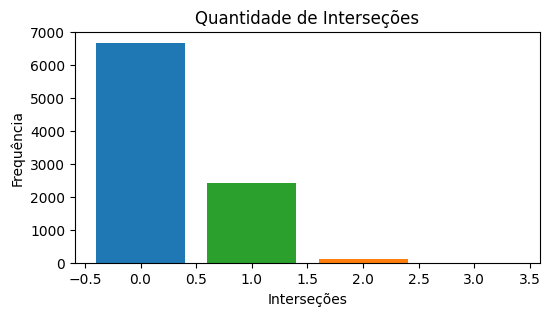

In [101]:
figure, ax = plt.subplots(1,1, figsize=(6,3))
data_colors = ["tab:blue", "tab:green", "tab:orange", "tab:red"]
plot_bars(axes=ax, data_values=counts, data_labels=intersects, title="Quantidade de Interseções", x_label="Interseções", y_label="Frequência", data_colors=data_colors)
plt.show()

In [103]:
intersects, counts

(array([0, 1, 2, 3]), array([6672, 2431,  102,    1]))

Na tabela abaixo, mostramos as ofertas por ordem decrescente de recomendações, ou seja, das mais recomendadas para as menos recomendadas. Percebemos algumas informações bem interessantes:

- Primeiro que as ofertas mais recomendadas são aquelas que trazem algum benefício direto para o cliente, seja **desconto** ou **bogo**. Ao passo que as ofertas de **informações** foram as menos recomendadas.
- Vemos também que a oferta mais recomendada foi a de **desconto**, com o **maior tempo de duração (10)** e utilizando **todos os canais**. Outra oferta de desconto com a mesma duração foi bem menos recomendada (posição 7), mas vemos que, apesar de ter um valor de desconto maior (5), ela necessitava de um valor mínimo muito grande (20) em relação ao restante e foi divulgada apenas por emal e web.
- As top 3 ofertas mais recomendadas foram divulgadas em todos os canais, o que pode indicar que a divulgação ampla pode ser uma estratégia interessante.
- Vemos também que pode haver um trade-off entre **valor mínimo** e **valor do desconto** para a escolha entre **bogo** e **desconto**. Quando o valor mínimo se torna mais alto em comparação ao desconto a ser recebido, o **bogo** ganha do **desconto** em recomendações.


In [112]:
offers_exploded = top3_recommends_per_user.select(
    "account_id_int",
    explode("recommendations").alias("rec")
).select(
    col("rec.offer_id_int").alias("offer_id_int"),
    col("rec.rating").alias("predicted_rating"))

offers_count = offers_exploded.groupBy("offer_id_int") \
    .agg(count("*").alias("num_recommendations"))

top_offers = offers_count.orderBy(desc("num_recommendations"))
top_offers = map_back_from_int_to_id(data=top_offers, column_map=map_int_to_offer_id, original_column_name="offer_id_int", new_column_name="id")
top_offers.show(10, truncate=False)

+--------------------------------+-------------------+
|id                              |num_recommendations|
+--------------------------------+-------------------+
|fafdcd668e3743c1bb461111dcafc2a4|16248              |
|2298d6c36e964ae4a3e7e9706d1fb8c2|14190              |
|f19421c1d4aa40978ebb69ca19b0e20d|8317               |
|9b98b8c7a33c4b65b9aebfe6a799e6d9|2954               |
|ae264e3637204a6fb9bb56bc8210ddfd|2585               |
|4d5c57ea9a6940dd891ad53e9dbe8da0|2497               |
|2906b810c7d4411798c6938adc9daaa5|2297               |
|0b1e1539f2cc45b7b9fa7c272da2e1d7|1372               |
|3f207df678b143eea3cee63160fa8bed|52                 |
|5a8bc65990b245e5a138643cd4eb9837|38                 |
+--------------------------------+-------------------+



In [118]:
path_offers = "ifood-case/data/raw/offers.json"
df_offers = spark.read.json(path_offers)

top_offers_enriched = top_offers.join(
    df_offers,
    on="id",    # chave de junção
    how="left"        # mantém todas as ofertas do ranking
)

top_offers_enriched.orderBy(desc("num_recommendations")).show(truncate=False)

+--------------------------------+-------------------+----------------------------+--------------+--------+---------+-------------+
|id                              |num_recommendations|channels                    |discount_value|duration|min_value|offer_type   |
+--------------------------------+-------------------+----------------------------+--------------+--------+---------+-------------+
|fafdcd668e3743c1bb461111dcafc2a4|16248              |[web, email, mobile, social]|2             |10.0    |10       |discount     |
|2298d6c36e964ae4a3e7e9706d1fb8c2|14190              |[web, email, mobile, social]|3             |7.0     |7        |discount     |
|f19421c1d4aa40978ebb69ca19b0e20d|8317               |[web, email, mobile, social]|5             |5.0     |5        |bogo         |
|9b98b8c7a33c4b65b9aebfe6a799e6d9|2954               |[web, email, mobile]        |5             |7.0     |5        |bogo         |
|ae264e3637204a6fb9bb56bc8210ddfd|2585               |[email, mobile, social

Diversas outras perguntas poderiam ser exploradas com essas informações e informações adicionais. Por exemplo:
- As ofertas recomendadas tem algo em comum com as ofertas com as quais os usuários já interagiram?
- As ofertas que tiveram interseções estão em que posição nas recomendações (mais forte, do meio, mais fraca)?
- Qual a expectativa de que o usuário veja e complete as ofertas preditas?
- etc...

Elas ficarão para trabalhos futuros.